# Session 4 — Regularization, Validation, and the Data Leakage Problem in Preprocessing
**Overview of today's session**This session builds directly on the linear regression foundations covered previously and addresses three closely related problems that arise once a model is no longer perfectly simple:1. **Regularization** — how to constrain model complexity (Lasso, Ridge, ElasticNet) so that a model does not simply memorize the training data.2. **Validation** — how to *measure* whether a model generalizes well, using quantitative metrics for both regression and classification tasks.3. **The correct order of operations in preprocessing** — specifically, *why* fitting a scaler before splitting the data into train/test sets introduces **data leakage**, and how a Scikit-learn `Pipeline` prevents this systematically.4. **Handling missing values and outliers** as part of a reproducible preprocessing pipeline.5. **Polynomial feature engineering** as a way to let a linear model capture non-linear relationships, and how to select the polynomial degree without overfitting, using a real dataset (`web_traffic.tsv`).The unifying theme across all of these topics is **generalization**: every technique below exists to make sure the model's performance on unseen data is a reliable estimate of its real-world performance, rather than an artifact of how the data was prepared or how complex the model was allowed to become.

# Regularization

We dont care whiche approche  you soupus to use it (Regrezssor or classifier), gor regularizer we have this ways to calculating them

**Why regularization matters**Regularization adds a penalty term to the model's loss function that discourages large coefficient values. This is important regardless of whether the underlying task is regression or classification, because in both cases an unconstrained model can fit noise in the training data (overfitting), which increases variance and harms performance on new data.The three linear-model variants imported above differ in *which* penalty they apply:- **Ridge (L2 penalty)**: penalizes the sum of squared coefficients. Shrinks coefficients toward zero but rarely sets them exactly to zero. Useful when most features are expected to contribute at least a little.- **Lasso (L1 penalty)**: penalizes the sum of absolute coefficients. Can shrink some coefficients to exactly zero, effectively performing feature selection.- **ElasticNet**: a weighted combination of L1 and L2 penalties, useful when features are correlated (a weakness of pure Lasso) while still retaining some sparsity.`SGDRegressor` is listed as an alternative because it optimizes a linear model using stochastic gradient descent and can apply any of these penalties (`penalty='l1'/'l2'/'elasticnet'`) via a parameter rather than a dedicated class. It is typically preferred over `Lasso`/`Ridge`/`ElasticNet` when the dataset is too large to fit in memory or when an online/incremental learning setup is required.

In [1]:
from sklearn.linear_model import Lasso ,Ridge ,ElasticNet
# or 
from sklearn.linear_model import SGDRegressor

# Validation

**in regressore** approche we can use this metrices for validate our results :

**Why these specific metrics**- **MAE (Mean Absolute Error)**: average magnitude of errors in the same unit as the target, robust to outliers, but does not penalize large errors more than small ones.- **MSE (Mean Squared Error)**: squares each error before averaging, so large errors are penalized disproportionately more than small ones. This makes it sensitive to outliers.- **RMSE (Root Mean Squared Error)**: the square root of MSE, which returns the error to the original unit of the target variable, making it more interpretable than MSE while retaining the same sensitivity to large errors.- **R² (Coefficient of Determination)**: measures the proportion of variance in the target explained by the model, relative to a naive baseline that always predicts the mean. R² = 1 is a perfect fit, R² = 0 means the model performs no better than predicting the mean, and R² < 0 means the model performs *worse* than that naive baseline — an important diagnostic signal used later in this notebook when we detect overfitting.

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

**in classifier** approche we can use this metrices for validate our results :

**Why these specific metrics**- **Accuracy**: the overall fraction of correct predictions. It can be misleading on imbalanced datasets (e.g., 95% healthy vs. 5% cancer), since a model that always predicts the majority class can still score high accuracy.- **Precision**: of all instances predicted positive, the fraction that are actually positive. Important when false positives are costly.- **Recall (Sensitivity)**: of all actual positive instances, the fraction correctly identified. Important when false negatives are costly — as in the cancer-detection example below, where missing a true positive case is far more dangerous than a false alarm.- **F1-score**: the harmonic mean of precision and recall, useful as a single summary metric when both false positives and false negatives matter and the class distribution is imbalanced.- **RocCurveDisplay**: visualizes the trade-off between true positive rate and false positive rate across all classification thresholds, rather than a single fixed threshold (0.5 by default).The worked example below (`y_true` vs. `y_pred` for a healthy/cancer classification) is intentionally chosen so that recall for the "cancer" class is emphasized: a false negative (predicting healthy when the patient has cancer) is clinically far more harmful than a false positive, so recall is the metric to prioritize in this context even if it comes at the cost of precision.

In [3]:
from sklearn.metrics import accuracy_score, recall_score, precision_score , f1_score, RocCurveDisplay, classification_report

In [4]:
y_true=[0,0,0,0,0,1,1,1,1,1]
y_pred=[0,1,1,1,1,1,1,1,1,1]

In [5]:
print(classification_report(y_true,y_pred, target_names=['healthy','cancer']))

              precision    recall  f1-score   support

     healthy       1.00      0.20      0.33         5
      cancer       0.56      1.00      0.71         5

    accuracy                           0.60        10
   macro avg       0.78      0.60      0.52        10
weighted avg       0.78      0.60      0.52        10



## Data Leakage in Preprocessing:
Why the Order of Operations MattersBefore comparing the two approaches below, it is worth stating the general principle explicitly: **any transformation whose parameters are learned from data (e.g., mean/std for scaling, min/max for normalization) must be fit *only* on the training set.** If it is fit on the full dataset (train + test combined) before splitting, information about the test set's distribution leaks into the transformation parameters, and by extension into the training process. This is called **data leakage**, and it causes validation metrics to be overly optimistic — the model appears to generalize well, when in reality part of the test set's information was already available to it during training.

## The wrong way

**The wrong way, demonstrated below**: `StandardScaler` is fit on the *entire* array `X` (via `fit_transform`) before `train_test_split` is applied. The mean and standard deviation used to scale every point — including the ones that will later become the "unseen" test set — are computed using the test set's own values. This means the scaler has already "seen" the test data before the model is ever trained on the resulting training split.

In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [7]:
X = np.array([10,20,30,40,50,60,70,80,90,100]).reshape(-1,1)

scla=StandardScaler()
x_scaled  = scla.fit_transform(X)

In [8]:
x_train, x_test  = train_test_split(x_scaled, train_size=0.8, shuffle=False)

In [9]:
x_train

array([[-1.5666989 ],
       [-1.21854359],
       [-0.87038828],
       [-0.52223297],
       [-0.17407766],
       [ 0.17407766],
       [ 0.52223297],
       [ 0.87038828]])

In [10]:
x_test

array([[1.21854359],
       [1.5666989 ]])

Notice that `x_train` and `x_test` above were scaled *together*, as part of the same `fit_transform` call on `X`, prior to splitting. The takeaway:

# we have to scale the data after split our datasets 

## The correct way

**The correct way, demonstrated below**: the split happens *first*, on the raw (unscaled) data. Only afterward is `StandardScaler` fit — and critically, it must be fit **only on `x_train`**. The test set must never influence the parameters used to transform it.

In [11]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [12]:
X = np.array([10,20,30,40,50,60,70,80,90,100]).reshape(-1,1)
x_train, x_test  = train_test_split(X, train_size=0.8, shuffle=False)

In [13]:
scl=StandardScaler()
x_train_scaled  = scl.fit_transform(x_train)

`fit_transform` is legitimate here because `x_train` is the only data the scaler is allowed to learn from. The resulting mean and standard deviation belong exclusively to the training distribution.

In [14]:
x_train_scaled    # we have different numbers now✔✔✔💥

array([[-1.52752523],
       [-1.09108945],
       [-0.65465367],
       [-0.21821789],
       [ 0.21821789],
       [ 0.65465367],
       [ 1.09108945],
       [ 1.52752523]])

**Important correction:** the cell below still contains a subtler version of the same leakage problem. It creates a *new* `StandardScaler` and calls `fit_transform` on `x_test`, which means the test data is scaled using **its own** mean and standard deviation rather than the ones learned from the training set. The methodologically correct call is:```pythonx_test_scaled = scl.transform(x_test)   # reuse the SAME scaler fit on x_train, no new fitting```Using `.transform()` (not `.fit_transform()`) with the scaler that was already fit on `x_train` ensures the test set is transformed consistently with how the model was trained — which is the entire point of separating train and test statistics in the first place.

In [15]:
scl=StandardScaler()
x_test_scaled  = scl.fit_transform(x_test)

In [16]:
x_test_scaled

array([[-1.],
       [ 1.]])

# Pipline 

### start proj by pipline:

While Scikit-learn pipelines don’t automate data splitting or eliminate the need for tuning regularization, they significantly **reduce the risk of data leakage** during cross-validation. **By encapsulating preprocessing and model training** into a single unit, pipelines ensure that each step is applied consistently, allowing you to focus on hyperparameter optimization and model evaluation with greater confidence.

**Why a pipeline solves the leakage problem structurally**The manual approach above requires the developer to *remember* the correct order (split → fit scaler on train only → transform test) every single time, including inside cross-validation loops where the data is split repeatedly. A `Pipeline` removes this burden: when `pipeline.fit(x_train, y_train)` is called, every step's `fit` (e.g., the scaler's mean/std) is learned exclusively from `x_train`; when `pipeline.predict(x_test)` is called, each step's `transform` is applied using parameters already learned, never refitting on `x_test`. This is why pipelines are considered best practice for any workflow that includes cross-validation or hyperparameter search — they make the correct (leakage-free) behavior the default rather than something that must be manually re-verified at every step.

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import yfinance as yf

In [18]:
X=np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
y=np.array([1,2,3,4,5,6,7,8,9,10])

In [19]:
x_train , x_test , y_train , y_test = train_test_split(X,y, train_size=0.8)

In [30]:
#scal =StandardScaler()
#x_train_scaled = scal.fit_transform(x_train)
#x_train_scaled

array([[-1.52055974],
       [ 1.4284046 ],
       [-0.04607757],
       [ 1.05978406],
       [ 0.32254297],
       [-0.78331865],
       [-1.15193919],
       [ 0.69116352]])

In [27]:
#model  = LinearRegression()
#model.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.03]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.125
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[2.83]


In [31]:
#x_test_scaled = scal.transform(x_test)
#x_test_scaled

array([[ 1.79702514],
       [-0.41469811]])

In [32]:
#model.predict(x_test_scaled)

array([5.07598212, 5.13631182])

In [25]:
from sklearn.pipeline import Pipeline

In [35]:
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',model)
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None


In [36]:
pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](1,)",[5.12]


In [37]:
pipeline.predict(x_test)

array([10.,  4.])

In [38]:
import pickle 

In [39]:
with open('model.pkl' , 'wb') as f:
    pickle.dump(pipeline, f)

In [40]:
with open('model.pkl','rb') as f:
    model = pickle.load(f)

# impute 

**Why imputation is necessary**Most Scikit-learn estimators cannot handle missing values (`NaN`) directly and will raise an error during `fit`. Imputation replaces missing values with a plausible estimate so the pipeline can proceed, but the *strategy* chosen affects downstream model quality:- **`SimpleImputer`** replaces missing values with a single summary statistic per column (mean, median, most frequent, or a constant). It is fast and simple but ignores relationships between features.- **`KNNImputer`** estimates a missing value using the average of the `k` nearest neighboring rows (based on the other, non-missing features), which can produce more accurate estimates when features are correlated, at a higher computational cost.As with scaling, the imputer's statistics (e.g., the median used by `SimpleImputer`, or the neighbor distances used by `KNNImputer`) must be learned from the training set only, for the same data-leakage reasons discussed above — hence why imputation is placed as a step inside the pipeline rather than applied to the full dataset beforehand.

In [41]:
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator

Example of using SimpleImputer method

In [4]:
import numpy as np
X=np.array([0,0,3,np.nan,5]).reshape(-1,1)
imputer = SimpleImputer(missing_values=np.nan , strategy='median' , fill_value=4)
imputer.fit_transform(X)
# imputer = SimpleImputer(missing_values=0,strategy='constant')
# imputer = SimpleImputer(missing_values=5,strategy='mean')

array([[0. ],
       [0. ],
       [3. ],
       [1.5],
       [5. ]])

Example of using KNNImputer method

In [5]:
import pandas as pd 
data=[
    {'a':10, 'b':10, 'c':6},
    {'a':10, 'b':10, 'c':5},
    {'a':10, 'b':10, 'c':np.nan},
    {'a':20, 'b':20, 'c':10},
    {'a':20, 'b':20, 'c':np.nan},
]

df=pd.DataFrame(data)
df

,a,b,c
0,10,10,6.0
1,10,10,5.0
2,10,10,NaN
3,20,20,10.0
4,20,20,NaN


In [6]:
knn_imputer = KNNImputer(n_neighbors=2)
knn_imputer.fit_transform(df)

array([[10. , 10. ,  6. ],
       [10. , 10. ,  5. ],
       [10. , 10. ,  5.5],
       [20. , 20. , 10. ],
       [20. , 20. ,  8. ]])

In [8]:
from sklearn.pipeline import Pipeline,FunctionTransformer

In [12]:
def my_preprocess():
    return X+2

In [16]:
with open('model.pkl','rb') as f:
    model = pickle.load(f)

In [18]:
pipeline = Pipeline([
    ('preprocess_def',FunctionTransformer(my_preprocess)),
    ('imputer',KNNImputer(n_neighbors=4)),
    ('scaler',StandardScaler()),
    ('model',model)
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess_def', ...), ('imputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function my_...0021C65068540>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDi

# Outleires

We can either remove outliers identified by methods like Local Outlier Factor (LOF), IQR, Mean+STD, DBSCAN, and One-Class SVM based on a specific percentage of the data before starting the pipeline, or we can encapsulate the outlier removal process within a custom transformer and integrate it directly into the pipeline.”

**Brief overview of the listed outlier-detection methods**- **IQR (Interquartile Range)**: flags points falling below Q1 − 1.5×IQR or above Q3 + 1.5×IQR; simple and effective for roughly unimodal, univariate distributions.- **Mean ± STD**: flags points beyond a chosen number of standard deviations from the mean; assumes an approximately normal distribution.- **Local Outlier Factor (LOF)**: a density-based method that compares the local density of a point to that of its neighbors, well-suited to datasets where "normal" density varies across regions.- **DBSCAN**: a density-based clustering algorithm; points that do not belong to any dense cluster are naturally treated as outliers/noise.- **One-Class SVM**: learns a boundary around the "normal" data in feature space and flags points falling outside it; useful for high-dimensional data.Wrapping outlier removal in a custom transformer (as shown below with `FunctionTransformer`) keeps it inside the pipeline for the same reason imputation and scaling are: the outlier boundary should be learned from the training data only, and applied consistently — not recomputed independently on the test set.

In [21]:
from sklearn.neighbors import LocalOutlierFactor

In [22]:
lof = LocalOutlierFactor(n_neighbors=2)
# or .....

In [23]:
def  custom_transformer():
    lof = LocalOutlierFactor(n_neighbors=2)
    #...
    return X

In [24]:
pipeline = Pipeline([
    ('Outlier_def',FunctionTransformer(custom_transformer)),
    ('preprocess_def',FunctionTransformer(my_preprocess)),
    ('imputer',KNNImputer(n_neighbors=4)),
    ('scaler',StandardScaler()),
    ('model',model)
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Outlier_def', ...), ('preprocess_def', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cus...0021C6513C900>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=No

**To execute a specific stage within a Scikit-learn pipeline without triggering the subsequent steps, one can access the desired step directly using the `named_steps` attribute and invoke its transform method.**

Example:

In [ ]:
pipeline = Pipeline([
    ('Outlier_def',FunctionTransformer(custom_transformer)),
    ('preprocess_def',FunctionTransformer(my_preprocess)),
    ('imputer',KNNImputer(n_neighbors=4)),
    ('scaler',StandardScaler()),
    ('model',model)
])

X_scaled = pipeline.named_steps['scaler'].transform(X_test)

## PolynomialFeatures with One Input Feature

When your dataset contains only one input feature, **PolynomialFeatures creates new features by raising that feature to different powers.**

Suppose your original feature is x. If you set the polynomial degree to d, the transformer generates:

1,x,x^2,x^3,…,x^d


The constant column 1 is usually included to represent the intercept term.
Example

Assume the input data is:

In [25]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

X = np.array([[2], [3], [4]])

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

print(X_poly)

[[ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]]


### Why do we do this? (The Main Purpose)

The primary goal is to enable a Linear Regression model to model a nonlinear relationship.

If the relationship between your input and output is curved (for example, y=ax^2+bx+c), a standard linear regression model cannot learn it because it only looks for a straight line. However, when you introduce the x^2 feature to the model using PolynomialFeatures, you are essentially telling the model: **Treat x^2 as if it were an independent, separate feature.** As a result, performing linear regression on these new features effectively results in a Polynomial Regression.


### Critical Technical Notes (Warnings)

**Overfitting:** If you increase the degree too high (for example, to 10 or 20), the model will attempt to pass through every single data point exactly. This makes the model overly complex, causing it to perform disastrously on new, unseen data (the Test set).

**Feature Scaling:** After using PolynomialFeatures and generating high-order powers (such as x^4 or x^5), the numerical values can become extremely large. It is crucial to immediately follow this step in your Pipeline with a StandardScaler or MinMaxScaler to prevent these large magnitudes from destabilizing or causing issues for the model.

**Number of Features:** As the degree increases, the number of features grows exponentially. However, since you only have one initial feature, this growth is manageable in your case (unlike scenarios with multiple features where interaction terms like x1⋅x2 are created, which cause a much more rapid expansion).

## Start Project

**Workflow for this project**This section applies the concepts above to a real dataset (daily web traffic vs. day number) in order to demonstrate the full **underfitting → overfitting → model selection** cycle:1. Split the data with `shuffle=False`, since this is time-ordered data — shuffling would let the model "see" future points interspersed with past ones during training, which does not reflect how the model would be used in practice (predicting the future from the past).2. Fit a plain `LinearRegression` first, to show that a straight line cannot capture the visibly non-linear trend in the traffic data (underfitting).3. Introduce `PolynomialFeatures` to let the same linear model fit a curved trend.4. Sweep the polynomial degree across a range and compare training vs. test error at each degree, in order to locate the point where the model transitions from underfitting to overfitting.

In [29]:
import pandas as pd 
df = pd.read_csv('web_traffic.tsv', sep='\t' )
df.dropna(inplace=True)
df.head(5)

,day,traffic
0,1,2272.0
2,3,1386.0
3,4,1365.0
4,5,1488.0
5,6,1337.0


In [30]:
import matplotlib.pyplot as plt 

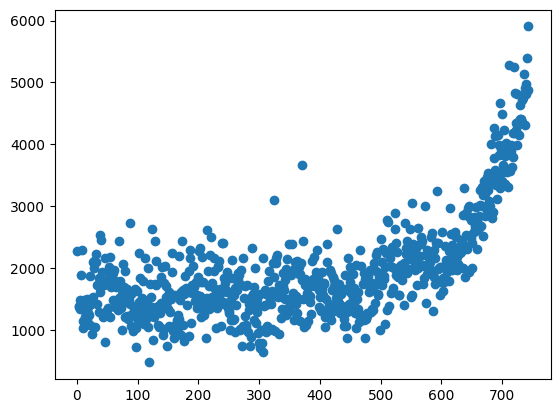

In [150]:
X=df['day'].values.reshape(-1,1)
y=df['traffic']
plt.scatter(X,y)

In [152]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import  LinearRegression
from sklearn.model_selection import train_test_split

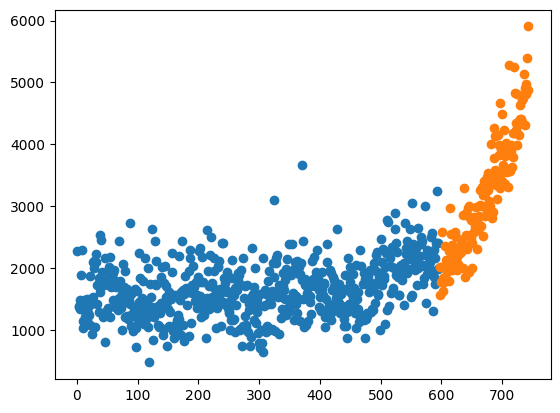

In [153]:
x_train, x_test, y_train , y_test = train_test_split(X,y,train_size=0.8, shuffle=False)
plt.scatter(x_train,y_train)
plt.scatter(x_test,y_test)

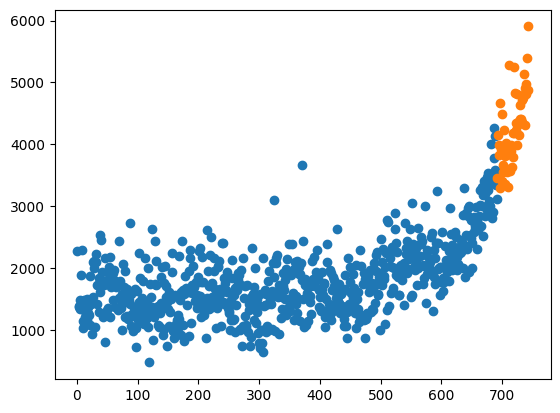

In [157]:
x_train, x_test, y_train , y_test = train_test_split(X,y,train_size=0.93, shuffle=False)
plt.scatter(x_train,y_train)
plt.scatter(x_test,y_test)

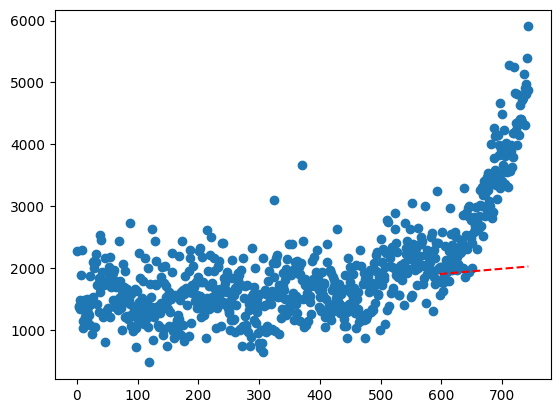

In [129]:
x_train, x_test, y_train , y_test = train_test_split(X,y,train_size=0.93, shuffle=False)
#-------------------------------------------------------
model = LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

plt.scatter(X,y)
plt.plot(x_test,y_pred,'r--')

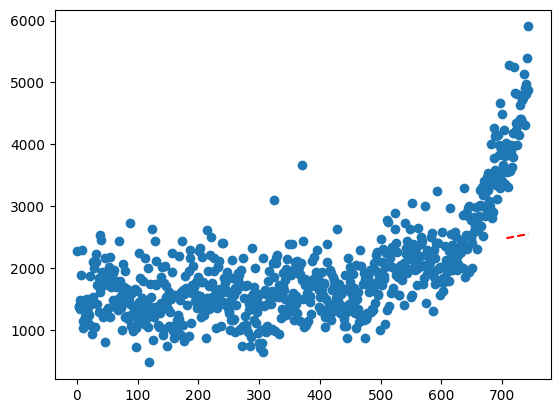

In [132]:
x_train, x_test, y_train , y_test = train_test_split(X,y,train_size=0.95, shuffle=False)
#-------------------------------------------------------
model = LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

plt.scatter(X,y)
#------------------
#plt.plot(X, y_pred, 'b' )
plt.plot(x_test,y_pred,'r--' )


In [133]:
a = model.coef_
b = model.intercept_
print('a:',a,'\n','b:',b)

a: [1.85631172] 
 b: 1170.389846979947


The coefficients above belong to a simple linear fit. Because the underlying trend in the traffic data is curved rather than linear, a single slope (`a`) and intercept (`b`) cannot capture it — this is the **underfitting** case that motivates introducing polynomial features next.

In [74]:
# We can fix this model by this feture by poly and crete new feature

In [134]:
from sklearn.preprocessing import PolynomialFeatures

In [158]:
x_train, x_test, y_train , y_test = train_test_split(X,y,train_size=0.90, shuffle=False)
model = LinearRegression()
#---------------------------------------
pnf = PolynomialFeatures(degree=3)
x_train_featured = pnf.fit_transform(x_train)     # x_train_poly 
x_test_featured = pnf.fit_transform(x_test)       # x_test_poly 
#--------------------------------------
model.fit(x_train_featured, y_train)
y_pred = model.predict(x_test_featured)

shape is (...,3)
we have(three) new features 

In [162]:
x_train_poly.shape , x_test_poly.shape , y_train.shape , y_test.shape, y_pred.shape

((661, 4), (74, 4), (661,), (74,), (74,))

In [163]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error , r2_score

degree:2 | RSME_train:413.155 - RSME_test:1391.055  | MAPE_train:0.214 - MAPE_test:0.299   | R2_train:0.346 - R2_test:-3.148
degree:3 | RSME_train:408.894 - RSME_test:1153.858  | MAPE_train:0.212 - MAPE_test:0.238   | R2_train:0.359 - R2_test:-1.854
degree:4 | RSME_train:408.243 - RSME_test:1007.646  | MAPE_train:0.211 - MAPE_test:0.202   | R2_train:0.361 - R2_test:-1.177
degree:5 | RSME_train:408.220 - RSME_test:930.978  | MAPE_train:0.211 - MAPE_test:0.184   | R2_train:0.361 - R2_test:-0.858
degree:6 | RSME_train:408.227 - RSME_test:912.842  | MAPE_train:0.211 - MAPE_test:0.180   | R2_train:0.361 - R2_test:-0.786
degree:7 | RSME_train:408.240 - RSME_test:946.931  | MAPE_train:0.211 - MAPE_test:0.187   | R2_train:0.361 - R2_test:-0.922
degree:8 | RSME_train:408.365 - RSME_test:1031.028  | MAPE_train:0.211 - MAPE_test:0.206   | R2_train:0.361 - R2_test:-1.279
degree:9 | RSME_train:408.699 - RSME_test:1165.975  | MAPE_train:0.212 - MAPE_test:0.234   | R2_train:0.360 - R2_test:-1.915
deg

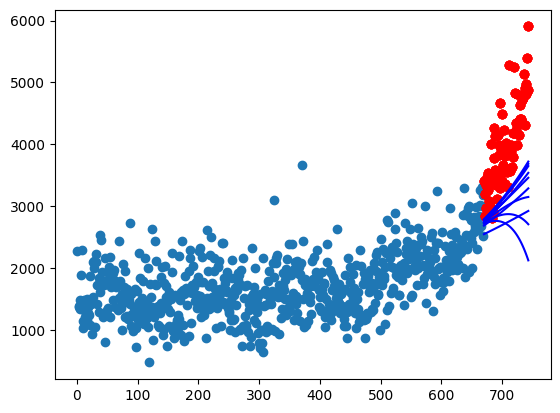

In [205]:
plt.scatter(x_train,y_train)
for degree in range(2,12):
    pnf = PolynomialFeatures(degree=degree)
    x_train_featured = pnf.fit_transform(x_train)  

    model = LinearRegression()
    model.fit(x_train_featured, y_train)

    x_test_featured = pnf.fit_transform(x_test)   
    
    y_pred_test = model.predict(x_test_featured)
    y_pred_train = model.predict(x_train_featured)  # why? beacuse of knowing about distance errors between train and test y and decided about exist of overfit 
    
    test_rmse = root_mean_squared_error(y_test, y_pred_test)
    train_rmse = root_mean_squared_error(y_train, y_pred_train)

    test_mape = mean_absolute_percentage_error(y_test, y_pred_test)
    train_mape = mean_absolute_percentage_error(y_train, y_pred_train)

    test_r2 = r2_score(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    
    plt.scatter(x_test, y_test, c='r', label='Test Data', alpha=0.5) 
    plt.plot(x_test, y_pred_test, c='b', label=f'Degree {degree}')
    #Verbose
    print(f'degree:{degree} | RSME_train:{train_rmse:.3f} - RSME_test:{test_rmse:.3f}  | MAPE_train:{train_mape:.3f} - MAPE_test:{test_mape:.3f}   | R2_train:{train_r2:.3f} - R2_test:{test_r2:.3f}')




**Note on this cell:** predictions are computed on *both* the train set (`y_pred_train`) and the test set (`y_pred_test`) at every degree, but the results are not yet stored or compared numerically here — that happens in the next cell using `root_mean_squared_error`. Comparing train and test error at each degree (rather than looking at test error alone) is exactly what lets us detect overfitting: as the polynomial degree grows, training error keeps decreasing (the curve fits the training points ever more closely), while test error eventually starts increasing again once the model begins fitting noise instead of the underlying trend.Also note: the cell below (`x_train_poly.shape , x_test_poly.shape ...`) references `x_train_poly`/`x_test_poly`, but the variables actually created in the loop above are named `x_train_featured`/`x_test_featured`. This will raise a `NameError` unless the variable names are made consistent.

**Note on this cell:** an empty list `Results` is initialized before the loop, presumably to collect a dictionary per degree (e.g., `{'Degree': degree, 'Model': model, 'RSME_train': train_rmse, 'RSME_test': test_rmse}`), which the next cell expects to convert into `df_result`. As written, however, nothing is appended to `Results` inside the loop, so `df_result` in the following cell would be built from an empty list. A line such as:```pythonResults.append({'Degree': degree, 'Model': model, 'RSME_train': train_rmse, 'RSME_test': test_rmse})```is needed at the end of the loop body for the subsequent model-selection step to work.

**Model Performance Analysis: Overfitting Detection**

The evaluation metrics reveal a significant discrepancy between the training and testing phases, which is a definitive indicator of overfitting (High Variance).

`R2 Score Discrepancy:` While the training R2 is 0.36, the test R2 drops drastically to −0.78. A negative R2 on the test set implies that the model performs worse than a horizontal line representing the mean of the data, failing to generalize the learned patterns to unseen observations.

`Error Metrics (RMSE):` The Root Mean Square Error (RMSE) more than doubles on the test set (increasing from 408.227 to 912.842). This substantial increase in error magnitude confirms that the model’s predictions become highly unreliable when applied to new data.

`MAPE Observation:` Although the MAPE shows a slightly lower error on the test set (0.180 vs 0.210), it does not compensate for the catastrophic failure observed in the R2 and RMSE metrics.

**Conclusion and Recommendation:**
The choice of degree=6 is too complex for the underlying structure of this dataset, causing the model to capture noise instead of the actual trend. To improve generalization, WE recommend **implementing regularization techniques (such as Ridge or Lasso regression) to penalize excessive coefficient magnitudes.**

In [244]:
Results= []
for degree in range(2,12):
    pnf = PolynomialFeatures(degree=degree)
    x_train_featured = pnf.fit_transform(x_train)  

    model = LinearRegression()
    model.fit(x_train_featured, y_train)

    x_test_featured = pnf.fit_transform(x_test)   
    
    y_pred_test = model.predict(x_test_featured)
    y_pred_train = model.predict(x_train_featured)  
    
    test_rmse = root_mean_squared_error(y_test, y_pred_test)
    train_rmse = root_mean_squared_error(y_train, y_pred_train)

    test_mape = mean_absolute_percentage_error(y_test, y_pred_test)
    train_mape = mean_absolute_percentage_error(y_train, y_pred_train)

    test_r2 = r2_score(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    
    result ={'Model':model,'Degree':degree,'RSME_train':train_rmse,'RSME_test':test_rmse,'MAPE_train':train_mape,'MAPE_test':test_mape,'R2_train':train_r2,'R2_test':test_r2}
    Results.append(result)

In [245]:
import pandas as pd
df_result = pd.DataFrame(Results)
#df.head(5)
df_result['RMSE_diff']=df_result ['RSME_train']- df_result['RSME_test']
RMSE_candidate_index = df_result['RMSE_diff'].abs().argmin()
df_result['RMSE_diff']

0    -977.900499
1    -744.963960
2    -599.402909
3    -522.757955
4    -504.614876
5    -538.691079
6    -622.662685
7    -757.276614
8    -945.132642
9   -1190.040804
Name: RMSE_diff, dtype: float64

In [246]:
df_result.iloc[RMSE_candidate_index]

Model         LinearRegression()
Degree                         6
RSME_train            408.227039
RSME_test             912.841915
MAPE_train              0.211218
MAPE_test                 0.1796
R2_train                0.361136
R2_test                -0.786401
RMSE_diff            -504.614876
Name: 4, dtype: object

**Why select degree by minimizing `|train_RMSE − test_RMSE|`**Rather than picking the degree with the single lowest test RMSE (which can itself be a somewhat noisy, high-variance choice on a small dataset), this notebook selects the degree where the training and test errors are *closest to each other*. A small gap between train and test error suggests the model's performance on unseen data closely matches its performance on data it was trained on — i.e., low variance / low overfitting — even if the absolute error is not the smallest achievable. This is a deliberate trade-off in favor of a model that generalizes predictably, over one that merely minimizes test error at a single point.

Objective: We aim to identify the optimal polynomial degree for each error metric.

Observations:

    RMSE: Degree 6 provides the lowest error according to the RMSE metric.
    MAPE: Degree 4 achieves the best performance in terms of MAPE.
    R2R2 Score: No consistent optimal degree is observed for the R2R2 metric, likely due to the high variance/overfitting issues."

In [250]:
RMSE_candidate_model = df_result.iloc[RMSE_candidate_index]['Model']
candidate_rmse_degree = df_result.iloc[RMSE_candidate_index]['Degree']

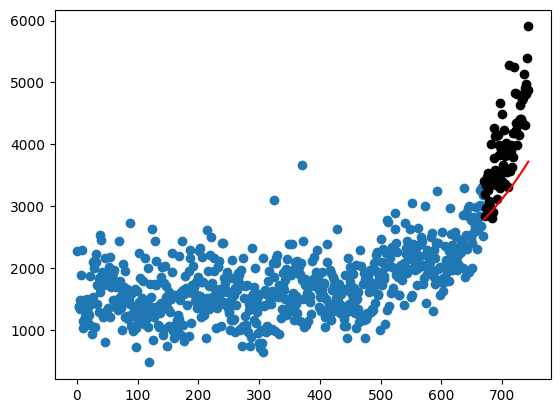

In [252]:
plt.scatter(x_train,y_train )
plt.scatter(x_test, y_test, c='k', label='Test Data') 

pnf = PolynomialFeatures(degree=candidate_rmse_degree)

x_test_featured = pnf.fit_transform(x_test)   
    
y_pred_test = RMSE_candidate_model.predict(x_test_featured)
plt.plot(x_test, y_pred_test, c='r')


**Why fit on the entire dataset here, after already selecting the degree via train/test comparison**The degree (6, chosen above) was selected using a proper train/test split, so this final step is not being used to *choose* the model — that decision is already made. Refitting on all the data afterward is purely for producing a smoother, visually complete curve across the entire time range for presentation purposes. This distinction matters: using held-out data for *model selection* and then optionally refitting on all available data for the *final deployed model* is common practice, but it should never be conflated with evaluating the model — the reported RMSE/R² figures still come from the earlier train/test comparison, not from this final full-data fit.

**WE CAN PLOT ALL** 

While fitting the model on the entire dataset may **not represent a true out-of-sample evaluation**, this visualization **is crucial** for qualitative analysis. It allows us to **visually inspect** how the polynomial curve captures the underlying trend and assists in selecting the optimal degree by observing the model’s fit to the data pattern

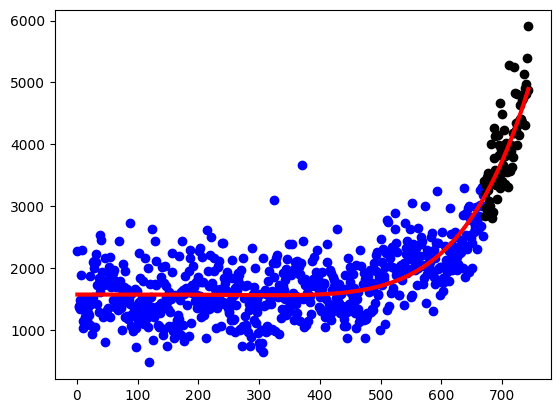

In [232]:
plt.scatter(x_train, y_train, c='b')
plt.scatter(x_test, y_test , c='k')

pnf = PolynomialFeatures(degree=6)
X_featured = pnf.fit_transform(X)

model = LinearRegression()
model.fit(X_featured,y)
y_pred = model.predict(X_featured)

plt.plot(X, y_pred, c='r', lw=3)